In [1]:
import os
import logging

# Đặt biến môi trường trước khi import TensorFlow
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'  # Thay thế cho việc gọi set_memory_growth
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Chỉ hiển thị FATAL
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Tắt autotuning để có kết quả nhất quán
logging.getLogger('tensorflow').setLevel(logging.FATAL)

In [2]:
# Thư viện chuẩn
import os
import time

# Thư viện xử lý dữ liệu và hiển thị
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Thư viện machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow và Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, 
    Dropout, 
    Flatten, 
    Conv2D, 
    BatchNormalization, 
    Activation, 
    MaxPooling2D,
    Input,
    Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, 
    EarlyStopping, 
    ReduceLROnPlateau, 
    TensorBoard
)

E0000 00:00:1744441202.973143      73 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744441203.032746      73 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Kiểm tra xem thiết lập có hiệu lực không
gpus = tf.config.list_physical_devices('GPU')
print(f"Số lượng GPU khả dụng: {len(gpus)}")
for gpu in gpus:
    print(f"  {gpu.name}")

# Không cần gọi set_memory_growth vì đã đặt qua biến môi trường
# Mixed precision vẫn có thể sử dụng được
mixed_precision = True
if mixed_precision:
    policy = tf.keras.mixed_precision.Policy('mixed_float16')
    tf.keras.mixed_precision.set_global_policy(policy)
    print("Đã kích hoạt mixed precision training")

Số lượng GPU khả dụng: 1
  /physical_device:GPU:0
Đã kích hoạt mixed precision training


In [4]:
def prepare_complete_fer_dataset_tf(
    folder_path, batch_size=128, val_size=0.1, random_state=42):
    """
    Đọc và xử lý dữ liệu FER từ thư mục:
    - Sử dụng thư mục test có sẵn nếu tồn tại
    - Chỉ tách validation từ train nếu thư mục validation không tồn tại
    
    Tham số:
        folder_path: Đường dẫn tới thư mục chứa dataset
        batch_size: Kích thước batch khi xử lý ảnh
        val_size: Tỷ lệ dữ liệu validation (chỉ áp dụng khi không có thư mục validation)
        random_state: Seed cho quá trình random
    
    Trả về:
        train_images, train_labels: Dữ liệu train
        val_images, val_labels: Dữ liệu validation
        test_images, test_labels: Dữ liệu test
        class_mapping: Dict ánh xạ số nguyên với tên cảm xúc
    """
    # Thiết lập TensorFlow sử dụng GPU
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            # Thiết lập chỉ sử dụng bộ nhớ khi cần
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"Đã tìm thấy {len(gpus)} GPU và thiết lập memory growth")
        except RuntimeError as e:
            print(f"Lỗi khi thiết lập GPU: {e}")
    else:
        print("Không tìm thấy GPU, sẽ sử dụng CPU")
    
    # Xác định các lớp cảm xúc
    emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    emotion_to_id = {emotion: i for i, emotion in enumerate(emotions)}
    id_to_emotion = {i: emotion for i, emotion in enumerate(emotions)}
    
    # Hàm đọc và tiền xử lý ảnh với TensorFlow
    @tf.function
    def preprocess_image(file_path):
        # Đọc file
        img_raw = tf.io.read_file(file_path)
        # Giải mã ảnh
        img = tf.image.decode_image(img_raw, channels=1, expand_animations=False)
        # Resize ảnh về 48x48
        img = tf.image.resize(img, [48, 48])
        # Ép kiểu về float32 và chuẩn hóa
        img = tf.cast(img, tf.float32) / 255.0
        return img
    
    # Hàm xử lý dữ liệu từ đường dẫn thành ảnh và nhãn
    def process_paths_to_data(paths, labels):
        # Tạo dataset TensorFlow
        path_ds = tf.data.Dataset.from_tensor_slices(paths)
        label_ds = tf.data.Dataset.from_tensor_slices(labels)
        
        # Kết hợp đường dẫn và nhãn
        ds = tf.data.Dataset.zip((path_ds, label_ds))
        
        # Áp dụng tiền xử lý
        processed_ds = ds.map(
            lambda path, label: (preprocess_image(path), label), 
            num_parallel_calls=tf.data.AUTOTUNE
        ).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        
        # Xử lý từng batch
        images = []
        processed_labels = []
        
        # Hiển thị tiến độ
        total_batches = len(paths) // batch_size + (1 if len(paths) % batch_size != 0 else 0)
        
        for images_batch, labels_batch in tqdm(processed_ds, total=total_batches, desc="Xử lý ảnh"):
            # Chuyển về numpy
            np_images = images_batch.numpy()
            np_labels = labels_batch.numpy()
            
            # Thêm vào danh sách
            images.extend(np_images)
            processed_labels.extend(np_labels)
        
        return np.array(images), np.array(processed_labels)
    
    # Hàm đọc dữ liệu từ một thư mục
    def read_from_directory(directory, dir_type):
        print(f"Đang đọc dữ liệu từ thư mục {dir_type}...")
        
        if not os.path.exists(directory):
            print(f"Thư mục {directory} không tồn tại.")
            return 0, [], []
        
        all_paths = []
        all_labels = []
        
        for emotion in emotions:
            emotion_path = os.path.join(directory, emotion)
            
            # Kiểm tra xem thư mục có tồn tại không
            if not os.path.exists(emotion_path):
                print(f"Thư mục {emotion_path} không tồn tại.")
                continue
            
            # Đọc tất cả file trong thư mục cảm xúc
            files = [f for f in os.listdir(emotion_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
            
            for img_file in tqdm(files, desc=f"{dir_type}/{emotion}"):
                img_path = os.path.join(emotion_path, img_file)
                
                # Thêm đường dẫn và nhãn vào danh sách
                all_paths.append(img_path)
                all_labels.append(emotion_to_id[emotion])
        
        return len(all_paths), all_paths, all_labels
    
    # Thiết lập seed cho quá trình random
    np.random.seed(random_state)
    tf.random.set_seed(random_state)
    
    # Đọc dữ liệu từ thư mục train
    train_path = os.path.join(folder_path, "train")
    train_count, train_paths, train_labels = read_from_directory(train_path, "train")
    
    # Đọc dữ liệu từ thư mục validation nếu có
    val_path = os.path.join(folder_path, "validation")
    val_count, val_paths, val_labels = read_from_directory(val_path, "validation")
    
    # Đọc dữ liệu từ thư mục test nếu có
    test_path = os.path.join(folder_path, "test")
    test_count, test_paths, test_labels = read_from_directory(test_path, "test")
    
    # === XỬ LÝ TÁCH DỮ LIỆU ===
    
    # Xử lý dữ liệu test riêng nếu có
    if test_count > 0:
        print("\nSử dụng thư mục test có sẵn...")
        test_images, test_labels = process_paths_to_data(test_paths, test_labels)
    else:
        print("\nKhông tìm thấy thư mục test!")
        test_images, test_labels = None, None
    
    # Xử lý dữ liệu validation
    if val_count > 0:
        print("\nSử dụng thư mục validation có sẵn...")
        val_images, val_labels = process_paths_to_data(val_paths, val_labels)
    else:
        print(f"\nKhông tìm thấy thư mục validation, sẽ tách {val_size*100:.0f}% từ tập train...")
        # Tách validation từ train
        train_indices, val_indices = train_test_split(
            np.arange(len(train_paths)),
            test_size=val_size,
            stratify=train_labels,
            random_state=random_state
        )
        
        # Phân chia đường dẫn
        val_paths_split = [train_paths[i] for i in val_indices]
        val_labels_split = [train_labels[i] for i in val_indices]
        
        # Cập nhật lại train paths và labels
        train_paths = [train_paths[i] for i in train_indices]
        train_labels = [train_labels[i] for i in train_indices]
        
        # Xử lý tập validation vừa tách
        val_images, val_labels = process_paths_to_data(val_paths_split, val_labels_split)
    
    # Xử lý dữ liệu train
    train_images, train_labels = process_paths_to_data(train_paths, train_labels)
    
    # In thống kê
    print("\n===== THỐNG KÊ DỮ LIỆU =====")
    print(f"Tập train: {len(train_images)} mẫu")
    print(f"Tập validation: {len(val_images)} mẫu")
    if test_images is not None:
        print(f"Tập test: {len(test_images)} mẫu")
    
    # Hiển thị phân phối các lớp
    print("\nPhân phối các lớp trong từng tập:")
    
    for name, subset_labels in [
        ("Train", train_labels), 
        ("Validation", val_labels if val_images is not None else None),
        ("Test", test_labels if test_images is not None else None)
    ]:
        if subset_labels is None:
            continue
            
        print(f"\n{name}:")
        unique, counts = np.unique(subset_labels, return_counts=True)
        for i, count in zip(unique, counts):
            emotion = emotions[i]
            print(f"  {emotion}: {count} mẫu ({count/len(subset_labels)*100:.1f}%)")
    
    # Tạo one-hot encoding cho train, val, test
    train_labels_onehot = tf.keras.utils.to_categorical(train_labels, num_classes=len(emotions))
    val_labels_onehot = tf.keras.utils.to_categorical(val_labels, num_classes=len(emotions))
    test_labels_onehot = None
    if test_images is not None:
        test_labels_onehot = tf.keras.utils.to_categorical(test_labels, num_classes=len(emotions))
    
    class_mapping = id_to_emotion
    
    # Trả về các tập dữ liệu đã xử lý
    return (
        train_images, train_labels_onehot, 
        val_images, val_labels_onehot, 
        test_images, test_labels_onehot if test_images is not None else None, 
        class_mapping
    )

# Cách sử dụng:
fer_folder_path = "/kaggle/input/fer2013"
fer_train_images, fer_train_labels, fer_val_images, fer_val_labels, fer_test_images, fer_test_labels, fer_class_mapping = prepare_complete_fer_dataset_tf(
    fer_folder_path, 
    batch_size=256, 
    val_size=0.2
)

Đã tìm thấy 1 GPU và thiết lập memory growth
Đang đọc dữ liệu từ thư mục train...


train/surprise: 100%|██████████| 3171/3171 [00:00<00:00, 1023008.84it/s]


Đang đọc dữ liệu từ thư mục validation...
Thư mục /kaggle/input/fer2013/validation không tồn tại.
Đang đọc dữ liệu từ thư mục test...


test/surprise: 100%|██████████| 831/831 [00:00<00:00, 1038577.66it/s]
I0000 00:00:1744441256.675448      73 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Sử dụng thư mục test có sẵn...


Xử lý ảnh: 100%|██████████| 29/29 [00:07<00:00,  3.94it/s]



Không tìm thấy thư mục validation, sẽ tách 20% từ tập train...


Xử lý ảnh: 100%|██████████| 90/90 [00:20<00:00,  4.37it/s]



===== THỐNG KÊ DỮ LIỆU =====
Tập train: 22967 mẫu
Tập validation: 5742 mẫu
Tập test: 7178 mẫu

Phân phối các lớp trong từng tập:

Train:
  angry: 3196 mẫu (13.9%)
  disgust: 349 mẫu (1.5%)
  fear: 3277 mẫu (14.3%)
  happy: 5772 mẫu (25.1%)
  neutral: 3972 mẫu (17.3%)
  sad: 3864 mẫu (16.8%)
  surprise: 2537 mẫu (11.0%)

Validation:
  angry: 799 mẫu (13.9%)
  disgust: 87 mẫu (1.5%)
  fear: 820 mẫu (14.3%)
  happy: 1443 mẫu (25.1%)
  neutral: 993 mẫu (17.3%)
  sad: 966 mẫu (16.8%)
  surprise: 634 mẫu (11.0%)

Test:
  angry: 958 mẫu (13.3%)
  disgust: 111 mẫu (1.5%)
  fear: 1024 mẫu (14.3%)
  happy: 1774 mẫu (24.7%)
  neutral: 1233 mẫu (17.2%)
  sad: 1247 mẫu (17.4%)
  surprise: 831 mẫu (11.6%)


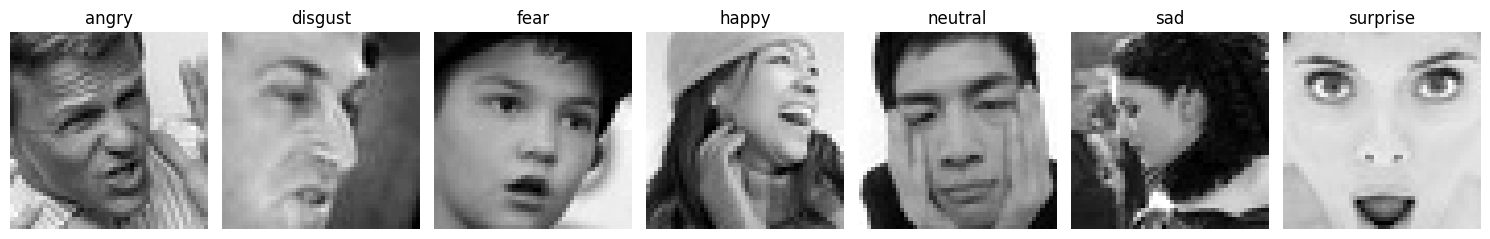

In [5]:
# Lấy một hình ảnh từ mỗi lớp của AffectNet để hiển thị
plt.figure(figsize=(15, 3))
for i, emotion in enumerate(fer_class_mapping.values()):
    # Tìm chỉ số của tất cả các hình ảnh thuộc lớp này
    indices = np.where(np.argmax(fer_train_labels, axis=1) == i)[0]
    if len(indices) > 0:
        # Chọn một hình ảnh ngẫu nhiên từ lớp này
        sample_idx = np.random.choice(indices)
        img = fer_train_images[sample_idx]

        # Hiển thị hình ảnh
        plt.subplot(1, 7, i + 1)
        plt.imshow(img.reshape(48, 48), cmap="gray")
        plt.title(emotion)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
def prepare_complete_affectnet_dataset(folder_path, batch_size=64, val_size=0.1, random_state=42):
    """
    Đọc và xử lý dữ liệu AffectNet từ thư mục:
    - Sử dụng thư mục test có sẵn nếu tồn tại
    - Chỉ tách validation từ train nếu thư mục validation không tồn tại
    
    Tham số:
        folder_path: Đường dẫn tới thư mục chứa AffectNet
        batch_size: Kích thước batch khi xử lý ảnh
        val_size: Tỷ lệ dữ liệu validation (chỉ áp dụng khi không có thư mục validation)
        random_state: Seed cho quá trình random
    
    Trả về:
        train_images, train_labels: Dữ liệu train
        val_images, val_labels: Dữ liệu validation 
        test_images, test_labels: Dữ liệu test
        class_mapping: Dict ánh xạ số nguyên với tên cảm xúc
    """
    # Ánh xạ từ thư mục AffectNet tới tên cảm xúc
    affectnet_emotions = {
        0: "angry",
        1: "disgust",
        2: "fear",
        3: "happy",
        4: "sad",
        5: "surprise",
        6: "neutral",
        7: "contempt",
    }

    # Mapping from AffectNet directory to emotion indices in the model
    # Ánh xạ từ cảm xúc AffectNet sang chỉ số cảm xúc trong mô hình
    # Lưu ý: AffectNet có 8 lớp, trong khi mô hình của chúng ta có 7 lớp (không có contempt)
    affectnet_to_model_mapping = {
        0: 0,  # angry -> angry
        1: 1,  # disgust -> disgust
        2: 2,  # fear -> fear
        3: 3,  # happy -> happy
        4: 5,  # sad -> sad
        5: 6,  # surprise -> surprise
        6: 4,  # neutral -> neutral
        7: None  # contempt -> không sử dụng
    }

    # Mapping back to display emotion names
    id_to_emotion = {
        0: "angry",
        1: "disgust",
        2: "fear",
        3: "happy",
        4: "neutral",
        5: "sad",
        6: "surprise"
    }
    # Thiết lập seed cho quá trình random
    np.random.seed(random_state)
    tf.random.set_seed(random_state)

    # Hàm tiền xử lý ảnh với TensorFlow
    @tf.function
    def preprocess_image(file_path):
        # Đọc file
        img_raw = tf.io.read_file(file_path)
        # Giải mã ảnh (hỗ trợ nhiều định dạng)
        img = tf.io.decode_image(img_raw, channels=3, expand_animations=False)
        # Chuyển sang grayscale
        img = tf.image.rgb_to_grayscale(img)
        # Resize về 48x48
        img = tf.image.resize(img, [48, 48])
        # Chuẩn hóa về khoảng [0, 1]
        img = tf.cast(img, tf.float32) / 255.0

        return img

    # Hàm xử lý dữ liệu từ đường dẫn thành ảnh và nhãn
    def process_paths_to_data(paths, labels):
        if not paths:
            return None, None

        # Tạo dataset TensorFlow
        path_ds = tf.data.Dataset.from_tensor_slices(paths)
        label_ds = tf.data.Dataset.from_tensor_slices(labels)

        # Kết hợp đường dẫn và nhãn
        ds = tf.data.Dataset.zip((path_ds, label_ds))

        # Áp dụng tiền xử lý
        processed_ds = ds.map(
            lambda path, label: (preprocess_image(path), label), 
            num_parallel_calls=tf.data.AUTOTUNE
        ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

        # Xử lý từng batch
        images = []
        processed_labels = []

        # Hiển thị tiến độ
        total_batches = len(paths) // batch_size + (1 if len(paths) % batch_size != 0 else 0)

        for images_batch, labels_batch in tqdm(processed_ds, total=total_batches, desc="Xử lý ảnh"):
            # Chuyển về numpy
            np_images = images_batch.numpy()
            np_labels = labels_batch.numpy()

            # Thêm vào danh sách
            images.extend(np_images)
            processed_labels.extend(np_labels)

        return np.array(images), np.array(processed_labels)

    def read_from_directory(directory, dir_type):
        print(f"Đang đọc dữ liệu từ thư mục {dir_type}...")

        if not os.path.exists(directory):
            print(f"Thư mục {directory} không tồn tại.")
            return 0, [], []

        all_paths = []
        all_labels = []

        # Duyệt qua từng thư mục cảm xúc (0-7)
        for emotion_folder in range(8):
            # Bỏ qua "contempt" hoặc các cảm xúc không cần
            if (
                emotion_folder not in affectnet_to_model_mapping
                or affectnet_to_model_mapping[emotion_folder] is None
            ):
                continue

            # Nhãn đã ánh xạ sang mô hình hiện tại
            mapped_emotion = affectnet_to_model_mapping[emotion_folder]
            emotion_path = os.path.join(directory, str(emotion_folder))

            # Kiểm tra xem thư mục có tồn tại không
            if not os.path.exists(emotion_path):
                print(f"Thư mục {emotion_path} không tồn tại.")
                continue

            # Đọc tất cả file ảnh trong thư mục
            files = [f for f in os.listdir(emotion_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

            print(f"Tìm thấy {len(files)} ảnh trong {dir_type}/{affectnet_emotions[emotion_folder]}")

            # Tạo đường dẫn đầy đủ và nhãn
            for img_file in files:
                img_path = os.path.join(emotion_path, img_file)
                all_paths.append(img_path)
                all_labels.append(mapped_emotion)

        return len(all_paths), all_paths, all_labels

    # Đọc dữ liệu từ thư mục train
    train_path = os.path.join(folder_path, "train")
    train_count, train_paths, train_labels = read_from_directory(train_path, "train")

    # Đọc dữ liệu từ thư mục validation
    val_path = os.path.join(folder_path, "val")
    val_count, val_paths, val_labels = read_from_directory(val_path, "val")

    # Đọc dữ liệu từ thư mục test
    test_path = os.path.join(folder_path, "test")
    test_count, test_paths, test_labels = read_from_directory(test_path, "test")

    # === XỬ LÝ TÁCH DỮ LIỆU ===

    # Xử lý dữ liệu test riêng nếu có
    if test_count > 0:
        print("\nSử dụng thư mục test có sẵn...")
        test_images, test_labels = process_paths_to_data(test_paths, test_labels)
    else:
        print("\nKhông tìm thấy thư mục test!")
        test_images, test_labels = None, None

    # Xử lý dữ liệu validation
    if val_count > 0:
        print("\nSử dụng thư mục validation có sẵn...")
        val_images, val_labels = process_paths_to_data(val_paths, val_labels)
    else:
        print(f"\nKhông tìm thấy thư mục validation, sẽ tách {val_size*100:.0f}% từ tập train...")
        # Tách validation từ train
        train_indices, val_indices = train_test_split(
            np.arange(len(train_paths)),
            test_size=val_size,
            stratify=train_labels,
            random_state=random_state
        )

        # Phân chia đường dẫn
        val_paths_split = [train_paths[i] for i in val_indices]
        val_labels_split = [train_labels[i] for i in val_indices]

        # Cập nhật lại train paths và labels
        train_paths = [train_paths[i] for i in train_indices]
        train_labels = [train_labels[i] for i in train_indices]

        # Xử lý tập validation vừa tách
        val_images, val_labels = process_paths_to_data(val_paths_split, val_labels_split)

    # Xử lý dữ liệu train
    train_images, train_labels = process_paths_to_data(train_paths, train_labels)

    # In thống kê
    print("\n===== THỐNG KÊ DỮ LIỆU AFFECTNET =====")
    print(f"Tập train: {len(train_images)} mẫu")
    print(f"Tập validation: {len(val_images)} mẫu")
    if test_images is not None:
        print(f"Tập test: {len(test_images)} mẫu")

    # Hiển thị phân phối các lớp
    print("\nPhân phối các lớp trong từng tập:")

    for name, subset_labels in [
        ("Train", train_labels), 
        ("Validation", val_labels), 
        ("Test", test_labels if test_images is not None else None)
    ]:
        if subset_labels is None:
            continue

        print(f"\n{name}:")
        unique, counts = np.unique(subset_labels, return_counts=True)
        for i, count in zip(unique, counts):
            emotion = id_to_emotion[i]
            print(f"  {emotion}: {count} mẫu ({count/len(subset_labels)*100:.1f}%)")

    # Tạo one-hot encoding cho train, val, test
    train_labels_onehot = to_categorical(train_labels, num_classes=7)
    val_labels_onehot = to_categorical(val_labels, num_classes=7)
    test_labels_onehot = None
    if test_images is not None:
        test_labels_onehot = to_categorical(test_labels, num_classes=7)

    # Trả về các tập dữ liệu đã xử lý
    return (
        train_images, train_labels_onehot, 
        val_images, val_labels_onehot, 
        test_images, test_labels_onehot if test_images is not None else None, 
        id_to_emotion
    )

affectnet_folder_path = "/kaggle/input/affectnetaligned/AffectNetCustom"
affectnet_train_images, affectnet_train_labels, affectnet_val_images, affectnet_val_labels, affectnet_test_images, affectnet_test_labels, affectnet_class_mapping = prepare_complete_affectnet_dataset(
    affectnet_folder_path, 
    batch_size=256, 
)

Đang đọc dữ liệu từ thư mục train...
Tìm thấy 4999 ảnh trong train/angry
Tìm thấy 3801 ảnh trong train/disgust
Tìm thấy 4999 ảnh trong train/fear
Tìm thấy 4996 ảnh trong train/happy
Tìm thấy 4998 ảnh trong train/sad
Tìm thấy 4996 ảnh trong train/surprise
Tìm thấy 4999 ảnh trong train/neutral
Đang đọc dữ liệu từ thư mục val...
Tìm thấy 100 ảnh trong val/angry
Tìm thấy 99 ảnh trong val/disgust
Tìm thấy 100 ảnh trong val/fear
Tìm thấy 100 ảnh trong val/happy
Tìm thấy 100 ảnh trong val/sad
Tìm thấy 100 ảnh trong val/surprise
Tìm thấy 99 ảnh trong val/neutral
Đang đọc dữ liệu từ thư mục test...
Tìm thấy 400 ảnh trong test/angry
Tìm thấy 400 ảnh trong test/disgust
Tìm thấy 400 ảnh trong test/fear
Tìm thấy 400 ảnh trong test/happy
Tìm thấy 400 ảnh trong test/sad
Tìm thấy 399 ảnh trong test/surprise
Tìm thấy 400 ảnh trong test/neutral

Sử dụng thư mục test có sẵn...


Xử lý ảnh: 100%|██████████| 11/11 [00:04<00:00,  2.66it/s]



Sử dụng thư mục validation có sẵn...


Xử lý ảnh: 100%|██████████| 132/132 [00:50<00:00,  2.62it/s]


===== THỐNG KÊ DỮ LIỆU AFFECTNET =====
Tập train: 33788 mẫu
Tập validation: 698 mẫu
Tập test: 2799 mẫu

Phân phối các lớp trong từng tập:

Train:
  angry: 4999 mẫu (14.8%)
  disgust: 3801 mẫu (11.2%)
  fear: 4999 mẫu (14.8%)
  happy: 4996 mẫu (14.8%)
  neutral: 4999 mẫu (14.8%)
  sad: 4998 mẫu (14.8%)
  surprise: 4996 mẫu (14.8%)

Validation:
  angry: 100 mẫu (14.3%)
  disgust: 99 mẫu (14.2%)
  fear: 100 mẫu (14.3%)
  happy: 100 mẫu (14.3%)
  neutral: 99 mẫu (14.2%)
  sad: 100 mẫu (14.3%)
  surprise: 100 mẫu (14.3%)

Test:
  angry: 400 mẫu (14.3%)
  disgust: 400 mẫu (14.3%)
  fear: 400 mẫu (14.3%)
  happy: 400 mẫu (14.3%)
  neutral: 400 mẫu (14.3%)
  sad: 400 mẫu (14.3%)
  surprise: 399 mẫu (14.3%)


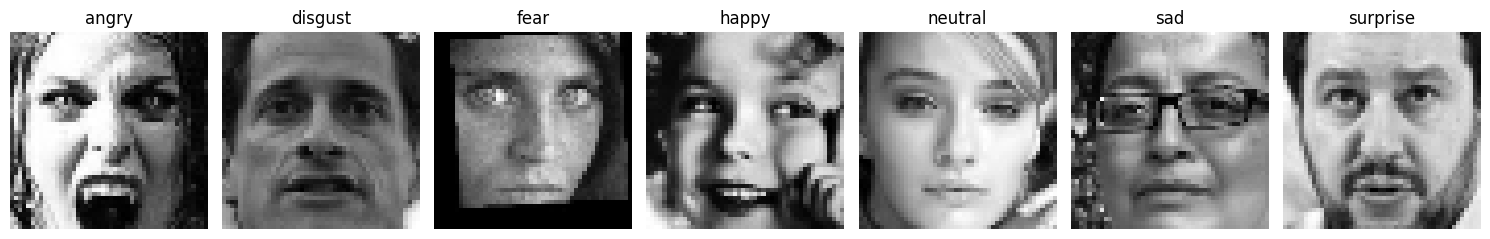

In [7]:
# Lấy một hình ảnh từ mỗi lớp của AffectNet để hiển thị
plt.figure(figsize=(15, 3))
for i, emotion in enumerate(affectnet_class_mapping.values()):
    # Tìm chỉ số của tất cả các hình ảnh thuộc lớp này
    indices = np.where(np.argmax(affectnet_train_labels, axis=1) == i)[0]
    if len(indices) > 0:
        # Chọn một hình ảnh ngẫu nhiên từ lớp này
        sample_idx = np.random.choice(indices)
        img = affectnet_train_images[sample_idx]
        
        # Hiển thị hình ảnh
        plt.subplot(1, 7, i+1)
        plt.imshow(img.reshape(48, 48), cmap='gray')
        plt.title(emotion)
        plt.axis('off')

plt.tight_layout()
plt.show()


In [8]:
def combine_datasets_with_splits(
    fer_train_images, fer_train_labels, 
    fer_val_images, fer_val_labels, 
    fer_test_images, fer_test_labels, 
    fer_mapping,
    
    affectnet_train_images, affectnet_train_labels, 
    affectnet_val_images, affectnet_val_labels, 
    affectnet_test_images, affectnet_test_labels, 
    affectnet_mapping,
    
    balance_strategy='equal', samples_per_class=None, random_seed=42):
    """
    Kết hợp dữ liệu từ FER và AffectNet đã tách thành các tập riêng biệt
    
    Tham số:
        fer_train_images, fer_train_labels: Dữ liệu huấn luyện FER
        fer_val_images, fer_val_labels: Dữ liệu validation FER
        fer_test_images, fer_test_labels: Dữ liệu test FER
        fer_mapping: Dict ánh xạ ID với tên cảm xúc FER
        
        affectnet_train_images, affectnet_train_labels: Dữ liệu huấn luyện AffectNet
        affectnet_val_images, affectnet_val_labels: Dữ liệu validation AffectNet
        affectnet_test_images, affectnet_test_labels: Dữ liệu test AffectNet
        affectnet_mapping: Dict ánh xạ ID với tên cảm xúc AffectNet
        
        balance_strategy: Chiến lược cân bằng dữ liệu
            - 'equal': Lấy số lượng mẫu bằng nhau từ mỗi nguồn cho mỗi lớp
            - 'proportional': Lấy tỷ lệ mẫu từ mỗi nguồn dựa trên kích thước ban đầu
            - 'all': Lấy tất cả mẫu từ cả hai nguồn
        
        samples_per_class: Số lượng mẫu tối đa cho mỗi lớp từ mỗi nguồn
            - None: Không giới hạn (chỉ áp dụng với 'all' và 'proportional')
            - int: Số lượng mẫu tối đa từ mỗi nguồn cho mỗi lớp (chỉ áp dụng với 'equal')
        
        random_seed: Hạt giống cho việc chọn mẫu ngẫu nhiên
    
    Trả về:
        combined_train_images, combined_train_labels: Dữ liệu huấn luyện kết hợp
        combined_val_images, combined_val_labels: Dữ liệu validation kết hợp
        combined_test_images, combined_test_labels: Dữ liệu test kết hợp
        class_mapping: Dict ánh xạ số nguyên với tên cảm xúc
    """
    print("===== KẾT HỢP HAI BỘ DỮ LIỆU (ĐÃ TÁCH TRAIN/VAL/TEST) =====")
    
    # Thiết lập seed cho tính tái lập
    np.random.seed(random_seed)
    tf.random.set_seed(random_seed)
    
    # Ánh xạ thống nhất cho cả hai bộ dữ liệu
    unified_emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    emotion_to_id = {emotion: i for i, emotion in enumerate(unified_emotions)}
    id_to_emotion = {i: emotion for i, emotion in enumerate(unified_emotions)}
    
    # Chuyển đổi từ one-hot encoding về nhãn số nguyên nếu cần
    def convert_from_onehot(labels):
        if labels is None:
            return None
        if len(labels.shape) > 1 and labels.shape[1] > 1:
            return np.argmax(labels, axis=1)
        return labels
    
    # Chuyển đổi từ nhãn số nguyên sang one-hot encoding
    def convert_to_onehot(labels, num_classes=7):
        if labels is None:
            return None
        return tf.keras.utils.to_categorical(labels, num_classes)
    
    # Chuyển đổi nhãn nếu cần
    fer_train_labels_int = convert_from_onehot(fer_train_labels)
    fer_val_labels_int = convert_from_onehot(fer_val_labels)
    fer_test_labels_int = convert_from_onehot(fer_test_labels)
    
    affectnet_train_labels_int = convert_from_onehot(affectnet_train_labels)
    affectnet_val_labels_int = convert_from_onehot(affectnet_val_labels)
    affectnet_test_labels_int = convert_from_onehot(affectnet_test_labels)
    
    # In thông tin các bộ dữ liệu
    print("\n--- THÔNG TIN BỘ DỮ LIỆU GỐC ---")
    print(f"FER Train: {fer_train_images.shape if fer_train_images is not None else 'None'}")
    print(f"FER Validation: {fer_val_images.shape if fer_val_images is not None else 'None'}")
    print(f"FER Test: {fer_test_images.shape if fer_test_images is not None else 'None'}")
    
    print(f"\nAffectNet Train: {affectnet_train_images.shape if affectnet_train_images is not None else 'None'}")
    print(f"AffectNet Validation: {affectnet_val_images.shape if affectnet_val_images is not None else 'None'}")
    print(f"AffectNet Test: {affectnet_test_images.shape if affectnet_test_images is not None else 'None'}")
    
    # Kiểm tra hình dạng ảnh và điều chỉnh nếu cần
    fer_shape = None
    affectnet_shape = None
    
    if fer_train_images is not None:
        fer_shape = fer_train_images.shape[1:]
    elif fer_val_images is not None:
        fer_shape = fer_val_images.shape[1:]
    elif fer_test_images is not None:
        fer_shape = fer_test_images.shape[1:]
    
    if affectnet_train_images is not None:
        affectnet_shape = affectnet_train_images.shape[1:]
    elif affectnet_val_images is not None:
        affectnet_shape = affectnet_val_images.shape[1:]
    elif affectnet_test_images is not None:
        affectnet_shape = affectnet_test_images.shape[1:]
    
    if fer_shape is not None and affectnet_shape is not None and fer_shape != affectnet_shape:
        print(f"\nCảnh báo: Kích thước ảnh khác nhau: FER {fer_shape} vs AffectNet {affectnet_shape}.")
        print("Đang điều chỉnh kích thước để phù hợp với nhau...")
        
        # Chọn target_shape là FER
        target_shape = fer_shape
        
        # Resize AffectNet nếu cần
        def resize_if_needed(images):
            if images is None:
                return None
            if images.shape[1:] != target_shape:
                print(f"Đang resize tập dữ liệu từ {images.shape[1:]} về {target_shape}...")
                resized = []
                images_tensor = tf.convert_to_tensor(images)
                resized_tensor = tf.image.resize(images_tensor, (target_shape[0], target_shape[1]))
                return resized_tensor.numpy()
            return images
        
        # Resize các tập dữ liệu AffectNet
        affectnet_train_images = resize_if_needed(affectnet_train_images)
        affectnet_val_images = resize_if_needed(affectnet_val_images)
        affectnet_test_images = resize_if_needed(affectnet_test_images)
    
    # Hàm lấy mẫu cân bằng cho một tập dữ liệu
    def get_balanced_subset(images, labels, source_name, split_name):
        if images is None or labels is None:
            return None, None
        
        result_images = []
        result_labels = []
        
        # Đếm số lượng mẫu cho mỗi lớp
        class_counts = {}
        for i in range(len(unified_emotions)):
            class_counts[i] = np.sum(labels == i)
        
        # In phân phối ban đầu
        print(f"\nPhân phối lớp {source_name} ({split_name}):")
        for i in range(len(unified_emotions)):
            print(f"  {unified_emotions[i]}: {class_counts[i]} mẫu")
        
        # Tính số lượng mẫu cần lấy cho mỗi lớp
        samples_to_take = {}
        
        for class_id in range(len(unified_emotions)):
            if class_counts[class_id] == 0:
                samples_to_take[class_id] = 0
                continue
                
            if balance_strategy == 'all' or samples_per_class is None:
                # Lấy tất cả
                samples_to_take[class_id] = class_counts[class_id]
            elif balance_strategy == 'equal':
                # Lấy số mẫu cố định hoặc tất cả nếu không đủ
                samples_to_take[class_id] = min(samples_per_class, class_counts[class_id])
            else:  # proportional - không áp dụng cho từng tập con
                samples_to_take[class_id] = class_counts[class_id]
        
        # Lấy mẫu cho từng lớp
        for class_id in range(len(unified_emotions)):
            if samples_to_take[class_id] == 0:
                continue
                
            class_indices = np.where(labels == class_id)[0]
            
            if samples_to_take[class_id] < len(class_indices):
                selected_indices = np.random.choice(class_indices, samples_to_take[class_id], replace=False)
            else:
                selected_indices = class_indices
            
            result_images.extend(images[selected_indices])
            result_labels.extend(np.full(len(selected_indices), class_id))
        
        return np.array(result_images), np.array(result_labels)
    
    # Lấy mẫu cân bằng cho từng tập FER
    fer_train_balanced_images, fer_train_balanced_labels = get_balanced_subset(
        fer_train_images, fer_train_labels_int, "FER", "Train")
    
    fer_val_balanced_images, fer_val_balanced_labels = get_balanced_subset(
        fer_val_images, fer_val_labels_int, "FER", "Validation")
    
    fer_test_balanced_images, fer_test_balanced_labels = get_balanced_subset(
        fer_test_images, fer_test_labels_int, "FER", "Test")
    
    # Lấy mẫu cân bằng cho từng tập AffectNet
    affectnet_train_balanced_images, affectnet_train_balanced_labels = get_balanced_subset(
        affectnet_train_images, affectnet_train_labels_int, "AffectNet", "Train")
    
    affectnet_val_balanced_images, affectnet_val_balanced_labels = get_balanced_subset(
        affectnet_val_images, affectnet_val_labels_int, "AffectNet", "Validation")
    
    affectnet_test_balanced_images, affectnet_test_balanced_labels = get_balanced_subset(
        affectnet_test_images, affectnet_test_labels_int, "AffectNet", "Test")
    
    # Gộp dữ liệu từ hai nguồn cho mỗi tập
    def combine_and_shuffle(images1, labels1, images2, labels2, split_name):
        print(f"\n--- Kết hợp tập {split_name} ---")
        
        # Kiểm tra nếu một trong hai tập không tồn tại
        if images1 is None or labels1 is None:
            print(f"Không có dữ liệu từ FER cho tập {split_name}")
            if images2 is None or labels2 is None:
                print(f"Không có dữ liệu từ cả hai nguồn cho tập {split_name}")
                return None, None
            
            print(f"Chỉ sử dụng dữ liệu từ AffectNet cho tập {split_name}")
            combined_images = images2
            combined_labels = labels2
        elif images2 is None or labels2 is None:
            print(f"Không có dữ liệu từ AffectNet cho tập {split_name}")
            print(f"Chỉ sử dụng dữ liệu từ FER cho tập {split_name}")
            combined_images = images1
            combined_labels = labels1
        else:
            # Gộp dữ liệu từ hai nguồn
            combined_images = np.concatenate([images1, images2], axis=0)
            combined_labels = np.concatenate([labels1, labels2], axis=0)
        
        # Trộn dữ liệu
        indices = np.arange(len(combined_images))
        np.random.shuffle(indices)
        
        shuffled_images = combined_images[indices]
        shuffled_labels = combined_labels[indices]
        
        # In thông tin
        print(f"  Tổng số mẫu: {len(shuffled_images)}")
        
        # Đếm số lượng mẫu cho mỗi lớp
        class_counts = {}
        for i in range(len(unified_emotions)):
            class_counts[i] = np.sum(shuffled_labels == i)
        
        # In phân phối
        for i in range(len(unified_emotions)):
            count = class_counts[i]
            if count > 0:
                print(f"  {unified_emotions[i]}: {count} mẫu ({count/len(shuffled_labels)*100:.1f}%)")
        
        return shuffled_images, convert_to_onehot(shuffled_labels, len(unified_emotions))
    
    # Gộp và trộn từng tập
    combined_train_images, combined_train_labels = combine_and_shuffle(
        fer_train_balanced_images, fer_train_balanced_labels,
        affectnet_train_balanced_images, affectnet_train_balanced_labels,
        "Train")
    
    combined_val_images, combined_val_labels = combine_and_shuffle(
        fer_val_balanced_images, fer_val_balanced_labels,
        affectnet_val_balanced_images, affectnet_val_balanced_labels,
        "Validation")
    
    combined_test_images, combined_test_labels = combine_and_shuffle(
        fer_test_balanced_images, fer_test_balanced_labels,
        affectnet_test_balanced_images, affectnet_test_balanced_labels,
        "Test")
    
    print("\n===== THỐNG KÊ TỔNG HỢP DỮ LIỆU KẾT HỢP =====")
    total_samples = 0
    if combined_train_images is not None:
        print(f"Train: {combined_train_images.shape}")
        total_samples += len(combined_train_images)
    
    if combined_val_images is not None:
        print(f"Validation: {combined_val_images.shape}")
        total_samples += len(combined_val_images)
    
    if combined_test_images is not None:
        print(f"Test: {combined_test_images.shape}")
        total_samples += len(combined_test_images)
    
    print(f"Tổng số mẫu: {total_samples}")
    
    return (
        combined_train_images, combined_train_labels,
        combined_val_images, combined_val_labels,
        combined_test_images, combined_test_labels,
        id_to_emotion
    )

# Kết hợp hai bộ dữ liệu
combined_train_images, combined_train_labels, combined_val_images, combined_val_labels, combined_test_images, combined_test_labels, combined_class_mapping = combine_datasets_with_splits(
    fer_train_images, fer_train_labels, 
    fer_val_images, fer_val_labels, 
    fer_test_images, fer_test_labels, 
    fer_class_mapping,
    
    affectnet_train_images, affectnet_train_labels, 
    affectnet_val_images, affectnet_val_labels, 
    affectnet_test_images, affectnet_test_labels, 
    affectnet_class_mapping,
    
    balance_strategy='all',  # Có thể chọn 'equal', 'proportional', hoặc 'all'
    samples_per_class=None,  # Chỉ áp dụng khi balance_strategy='equal'
    random_seed=42
)

# Kiểm tra kết quả
print(f"Train shape: {combined_train_images.shape}, {combined_train_labels.shape}")
print(f"Validation shape: {combined_val_images.shape}, {combined_val_labels.shape}")
print(f"Test shape: {combined_test_images.shape}, {combined_test_labels.shape}")

===== KẾT HỢP HAI BỘ DỮ LIỆU (ĐÃ TÁCH TRAIN/VAL/TEST) =====

--- THÔNG TIN BỘ DỮ LIỆU GỐC ---
FER Train: (22967, 48, 48, 1)
FER Validation: (5742, 48, 48, 1)
FER Test: (7178, 48, 48, 1)

AffectNet Train: (33788, 48, 48, 1)
AffectNet Validation: (698, 48, 48, 1)
AffectNet Test: (2799, 48, 48, 1)

Phân phối lớp FER (Train):
  angry: 3196 mẫu
  disgust: 349 mẫu
  fear: 3277 mẫu
  happy: 5772 mẫu
  neutral: 3972 mẫu
  sad: 3864 mẫu
  surprise: 2537 mẫu

Phân phối lớp FER (Validation):
  angry: 799 mẫu
  disgust: 87 mẫu
  fear: 820 mẫu
  happy: 1443 mẫu
  neutral: 993 mẫu
  sad: 966 mẫu
  surprise: 634 mẫu

Phân phối lớp FER (Test):
  angry: 958 mẫu
  disgust: 111 mẫu
  fear: 1024 mẫu
  happy: 1774 mẫu
  neutral: 1233 mẫu
  sad: 1247 mẫu
  surprise: 831 mẫu

Phân phối lớp AffectNet (Train):
  angry: 4999 mẫu
  disgust: 3801 mẫu
  fear: 4999 mẫu
  happy: 4996 mẫu
  neutral: 4999 mẫu
  sad: 4998 mẫu
  surprise: 4996 mẫu

Phân phối lớp AffectNet (Validation):
  angry: 100 mẫu
  disgust: 99 mẫu


===== THIẾT LẬP TĂNG CƯỜNG DỮ LIỆU CHO TẬP TRAIN =====
Xác nhận nhãn là one-hot với shape (56755, 7)
Số lượng mẫu train gốc: 56755
Số lượng mẫu train sau khi tăng cường: ~283775 (gấp 5 lần)

Phân phối các lớp trong tập train:
  Lớp 0: 8195 mẫu (14.4%)
  Lớp 1: 4150 mẫu (7.3%)
  Lớp 2: 8276 mẫu (14.6%)
  Lớp 3: 10768 mẫu (19.0%)
  Lớp 4: 8971 mẫu (15.8%)
  Lớp 5: 8862 mẫu (15.6%)
  Lớp 6: 7533 mẫu (13.3%)

Shape của batch ảnh: (128, 48, 48, 1)
Shape của batch nhãn: (128, 7)
Mẫu nhãn đầu tiên (xác nhận one-hot): [1. 0. 0. 0. 0. 0. 0.]


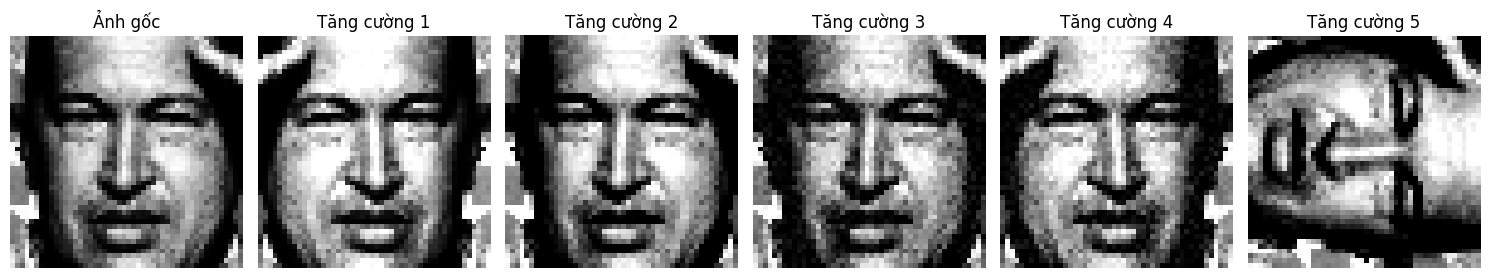

In [9]:
def augment_oneHot(image, onehot_label):
    """
    Hàm augment dữ liệu cho ảnh mà giữ nguyên nhãn one-hot
    """
    # Đảm bảo dữ liệu đầu vào không chứa NaN
    image = tf.debugging.check_numerics(image, "Input có giá trị NaN/Inf")

    # Lật ngang
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)

    # Điều chỉnh độ sáng (an toàn cho grayscale)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_brightness(image, 0.2)
        image = tf.clip_by_value(image, 0.0, 1.0)

    # Điều chỉnh độ tương phản (an toàn cho grayscale)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_contrast(image, 0.8, 1.2)
        image = tf.clip_by_value(image, 0.0, 1.0)

    # Xoay nhẹ 
    if tf.random.uniform(()) > 0.5:
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        image = tf.image.rot90(image, k)

    # Thêm nhiễu Gaussian nhẹ
    if tf.random.uniform(()) > 0.7:
        noise = tf.random.normal(tf.shape(image), 0, 0.05)
        image = image + noise
        image = tf.clip_by_value(image, 0.0, 1.0)

    # Kiểm tra kết quả cuối cùng
    image = tf.debugging.check_numerics(image, "Output có giá trị NaN/Inf")

    # Trả về ảnh đã tăng cường và giữ nguyên nhãn one-hot
    return image, onehot_label


def setup_train_augmentation(train_images, train_labels, batch_size=128, random_state=42):
    """
    Chỉ tăng cường dữ liệu cho tập train mà không phân chia lại dữ liệu
    
    Tham số:
        train_images: Mảng numpy chứa hình ảnh tập train
        train_labels: Mảng numpy chứa nhãn tập train (đã one-hot)
        batch_size: Kích thước batch
        random_state: Hạt giống cho quá trình random
    
    Trả về:
        train_ds: tf.data.Dataset chứa dữ liệu train đã tăng cường
    """
    print("\n===== THIẾT LẬP TĂNG CƯỜNG DỮ LIỆU CHO TẬP TRAIN =====")
    
    # Thiết lập seed
    tf.random.set_seed(random_state)
    np.random.seed(random_state)
    
    if len(train_labels.shape) == 1 or train_labels.shape[1] <= 1:
        raise ValueError("Nhãn phải ở định dạng one-hot encoding")
    else:
        print(f"Xác nhận nhãn là one-hot với shape {train_labels.shape}")
    
    
    # Dataset huấn luyện gốc
    train_ds_original = tf.data.Dataset.from_tensor_slices(
        (train_images, tf.cast(train_labels, tf.float32))
    )
    train_ds_original = train_ds_original.shuffle(buffer_size=len(train_images), seed=random_state)
    
    # Tạo các tập dữ liệu tăng cường
    train_ds_aug1 = train_ds_original.map(augment_oneHot, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds_aug2 = train_ds_original.map(augment_oneHot, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds_aug3 = train_ds_original.map(augment_oneHot, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds_aug4 = train_ds_original.map(augment_oneHot, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Kết hợp (gấp 5 lần dữ liệu)
    train_ds = (
        train_ds_original
        .concatenate(train_ds_aug1)
        .concatenate(train_ds_aug2)
        .concatenate(train_ds_aug3)
        .concatenate(train_ds_aug4)
    )
    
    # Hoàn thiện dataset
    train_ds = train_ds.batch(batch_size)
    train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
    
    # In thông tin
    print(f"Số lượng mẫu train gốc: {len(train_images)}")
    print(f"Số lượng mẫu train sau khi tăng cường: ~{len(train_images)*5} (gấp 5 lần)")
    
    print("\nPhân phối các lớp trong tập train:")
    # Chuyển from one-hot to class indices for counting
    class_indices = np.argmax(train_labels, axis=1)
    unique, counts = np.unique(class_indices, return_counts=True)
    total_samples = len(class_indices)
    
    for i, count in zip(unique, counts):
        print(f"  Lớp {i}: {count} mẫu ({count/total_samples*100:.1f}%)")
    
    # Kiểm tra định dạng nhãn trong dataset
    for image_batch, label_batch in train_ds.take(1):
        print(f"\nShape của batch ảnh: {image_batch.shape}")
        print(f"Shape của batch nhãn: {label_batch.shape}")
        print(f"Mẫu nhãn đầu tiên (xác nhận one-hot): {label_batch[0]}")
    
    return train_ds

# Hàm hiển thị ví dụ tăng cường
def visualize_augmentation_examples(sample_image, num_examples=5):
    """
    Hiển thị các ví dụ về tăng cường dữ liệu
    
    Tham số:
        sample_image: Ảnh mẫu để tăng cường
        num_examples: Số lượng ví dụ tăng cường cần hiển thị
    """
    # Chuyển đổi thành tensor
    image_tensor = tf.convert_to_tensor(sample_image)
    dummy_label = tf.zeros([1])  # Giả nhãn

    # Tạo danh sách ảnh để hiển thị
    augmented_images = [image_tensor]
    titles = ["Ảnh gốc"]

    # Tạo các phiên bản tăng cường
    for i in range(num_examples):
        aug_img, _ = augment_oneHot(image_tensor, dummy_label)
        augmented_images.append(aug_img)
        titles.append(f"Tăng cường {i+1}")

    # Hiển thị
    plt.figure(figsize=(3*num_examples, 3))

    for i, (img, title) in enumerate(zip(augmented_images, titles)):
        plt.subplot(1, num_examples+1, i+1)
        plt.imshow(img.numpy().squeeze(), cmap="gray")
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Tạo dataset train được tăng cường
train_ds = setup_train_augmentation(
    combined_train_images, 
    combined_train_labels,
    batch_size=128
)

# Tạo dataset validation và test (không tăng cường)
val_ds = tf.data.Dataset.from_tensor_slices((combined_val_images, combined_val_labels)) \
    .batch(128) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((combined_test_images, combined_test_labels)) \
    .batch(128) \
    .prefetch(tf.data.AUTOTUNE)

# Hiển thị ví dụ tăng cường
sample_idx = np.random.randint(0, len(combined_train_images))
visualize_augmentation_examples(combined_train_images[sample_idx], num_examples=5)

In [10]:
def residual_block(x, filters, kernel_size=3, dropout_rate=0.25):
    # Lưu lại đầu vào cho kết nối tắt
    residual = x

    # Conv + BN + ReLU
    x = Conv2D(filters, kernel_size, padding="same")(x)
    x = BatchNormalization(epsilon=1e-5)(x)
    x = Activation("relu")(x)

    # Conv + BN
    x = Conv2D(filters, kernel_size, padding="same")(x)
    x = BatchNormalization(epsilon=1e-5)(x)

    # Nếu kích thước khác nhau (số channels), thêm 1x1 conv cho residual
    if residual.shape[-1] != filters:
        residual = Conv2D(filters, (1, 1), padding="same")(residual)

    # Thêm kết nối tắt và áp dụng ReLU
    x = Add()([x, residual])
    x = Activation("relu")(x)

    # Thêm Pooling và Dropout như mô hình ban đầu
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(dropout_rate)(x)

    return x


# Xây dựng mô hình với Functional API
def build_resnet_model(input_shape=(48, 48, 1), num_classes=7):
    inputs = Input(shape=input_shape)

    # Block 1: 64 filters
    x = Conv2D(32, (3, 3), padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(64, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 2: 128 filters với residual connection
    x = residual_block(x, filters=128, kernel_size=(5, 5), dropout_rate=0.3)
    
    # Block 3: 256 filters với residual connection
    x = residual_block(x, filters=256, kernel_size=(3, 3), dropout_rate=0.35)

    # Block 4: 512 filters với residual connection
    x = residual_block(x, filters=512, kernel_size=(3, 3), dropout_rate=0.4)

    # Flatten và FC layers giống như mô hình ban đầu
    x = Flatten()(x)

    # FC layer 1
    x = Dense(256)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.45)(x)

    # FC layer 2
    x = Dense(512)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.5)(x)

    # Output layer
    outputs = Dense(num_classes, activation="softmax")(x)

    # Tạo model
    model = Model(inputs=inputs, outputs=outputs)

    return model


# Tạo model
model = build_resnet_model(num_classes=len(combined_class_mapping))

# Compile với cấu hình tương tự
opt = Adam(learning_rate=0.0003)
model.compile(
    optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 48, 48, 1)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast (Cast)               │ (None, 48, 48, 1)      │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 48, 48, 32)     │            320 │ cast[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 48, 48, 32)     │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 48, 48, 32)     │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 48, 48, 64)     │         18,496 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 48, 48, 64)     │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 48, 48, 64)     │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 24, 24, 64)     │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 24, 24, 64)     │              0 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 24, 24, 128)    │        204,928 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 24, 24, 128)    │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 24, 24, 128)    │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 24, 24, 128)    │        409,728 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 24, 24, 128)    │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 24, 24, 128)    │          8,320 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 24, 24, 128)    │              0 │ batch_normalization_3… │
│                      

 Total params: 6,557,319 (25.01 MB)

 Trainable params: 6,552,007 (24.99 MB)

 Non-trainable params: 5,312 (20.75 KB)

In [11]:
best_checkpoint = tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras', 
        save_best_only=True, 
        monitor='val_accuracy'
),

# 3. ReduceLROnPlateau với tùy chỉnh tốt hơn
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,          # Giảm nhẹ hơn (30% thay vì 20%)
    patience=4,          # Giảm patience xuống 4 epochs
    min_lr=5e-6,         # Tăng min_lr lên một chút
    verbose=1,
    cooldown=1           # Giảm cooldown xuống 1 epoch
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=6,          # Giảm patience xuống 6 epochs
    restore_best_weights=True,
    verbose=1,
    min_delta=0.003      # Giảm ngưỡng cải thiện xuống 0.3%
)

callbacks_list = [best_checkpoint, early_stopping, reduce_lr]

# Huấn luyện mô hình
epochs = 50
batch_size = 64

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks_list
)

Epoch 1/50


I0000 00:00:1744441430.644636     104 service.cc:148] XLA service 0x7ce1240034b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744441430.645557     104 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1744441432.218171     104 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/2217 ━━━━━━━━━━━━━━━━━━━━ 1:57 53ms/step - accuracy: 0.1543 - loss: 2.7684   

I0000 00:00:1744441451.760975     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2217/2217 ━━━━━━━━━━━━━━━━━━━━ 163s 57ms/step - accuracy: 0.1948 - loss: 2.1065 - val_accuracy: 0.4640 - val_loss: 1.4337 - learning_rate: 3.0000e-04
Epoch 2/50
2217/2217 ━━━━━━━━━━━━━━━━━━━━ 104s 47ms/step - accuracy: 0.4333 - loss: 1.4739 - val_accuracy: 0.5565 - val_loss: 1.1765 - learning_rate: 3.0000e-04
Epoch 3/50
2217/2217 ━━━━━━━━━━━━━━━━━━━━ 103s 47ms/step - accuracy: 0.5099 - loss: 1.2926 - val_accuracy: 0.5790 - val_loss: 1.1126 - learning_rate: 3.0000e-04
Epoch 4/50
2217/2217 ━━━━━━━━━━━━━━━━━━━━ 104s 47ms/step - accuracy: 0.5454 - loss: 1.2051 - val_accuracy: 0.6130 - val_loss: 1.0517 - learning_rate: 3.0000e-04
Epoch 5/50
2217/2217 ━━━━━━━━━━━━━━━━━━━━ 103s 46ms/step - accuracy: 0.5679 - loss: 1.1510 - val_accuracy: 0.6248 - val_loss: 1.0018 - learning_rate: 3.0000e-04
Epoch 6/50
2217/2217 ━━━━━━━━━━━━━━━━━━━━ 104s 47ms/step - accuracy: 0.5862 - loss: 1.1038 - val_accuracy: 0.6331 - val_loss: 0.9921 - learning_rate: 3.0000e-04
Epoch 7/50
2217/2217 ━━━━━━━━━━━━━━━━━━━━ 103

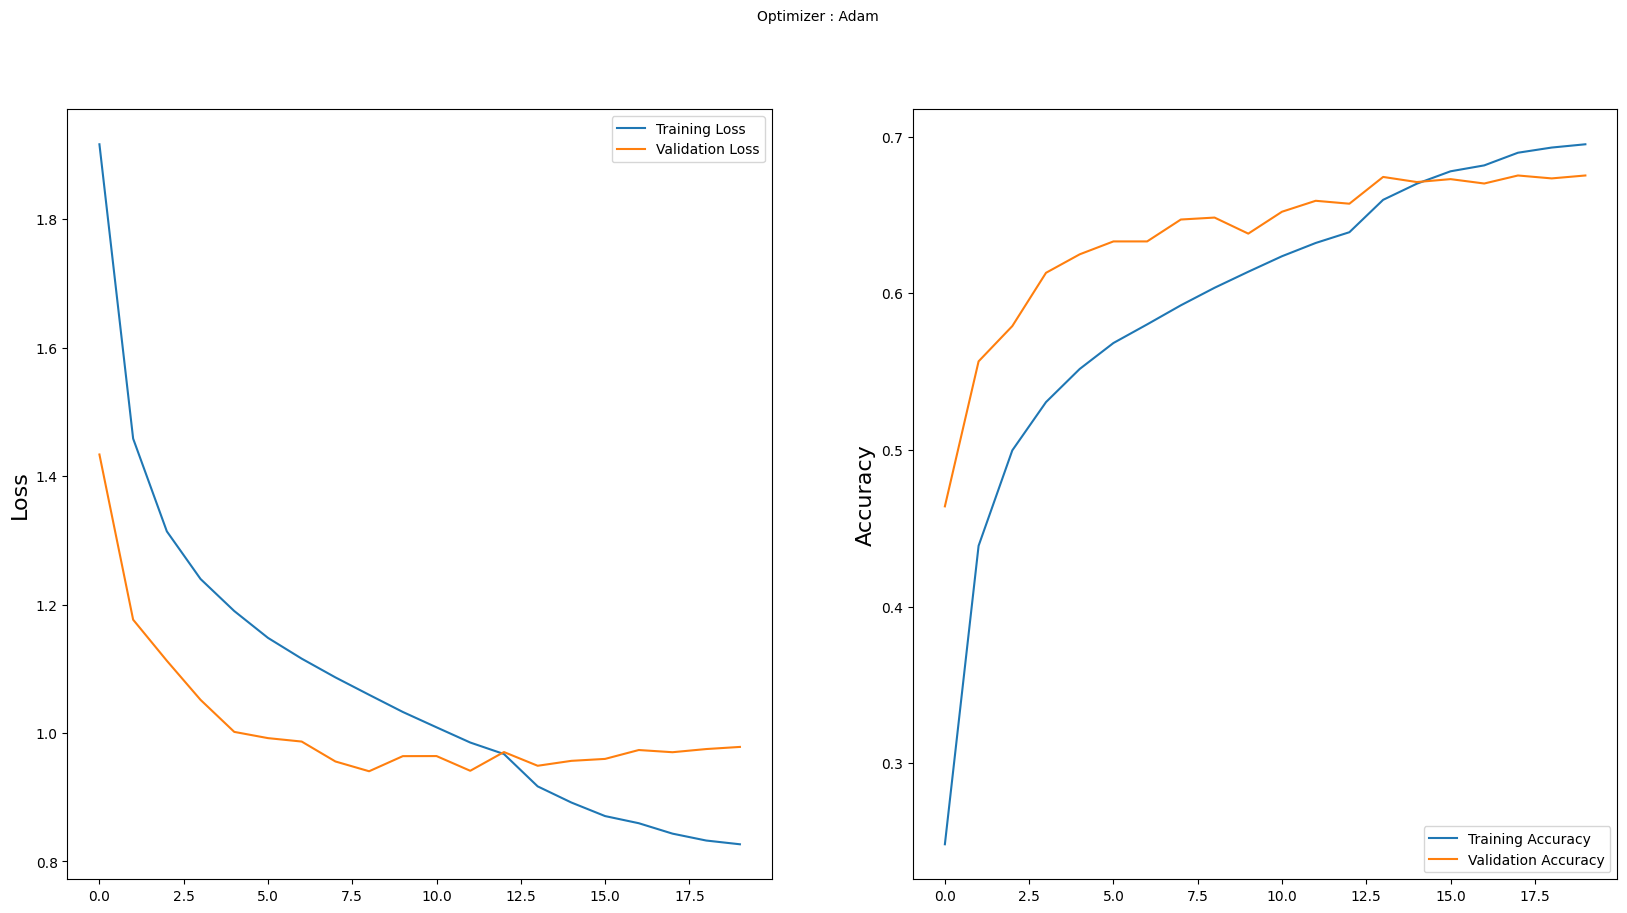

In [12]:
# Plotting Accuracy & Loss
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.suptitle("Optimizer : Adam", fontsize=10)
plt.ylabel("Loss", fontsize=16)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend(loc="upper right")

plt.subplot(1, 2, 2)
plt.ylabel("Accuracy", fontsize=16)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend(loc="lower right")
plt.show()

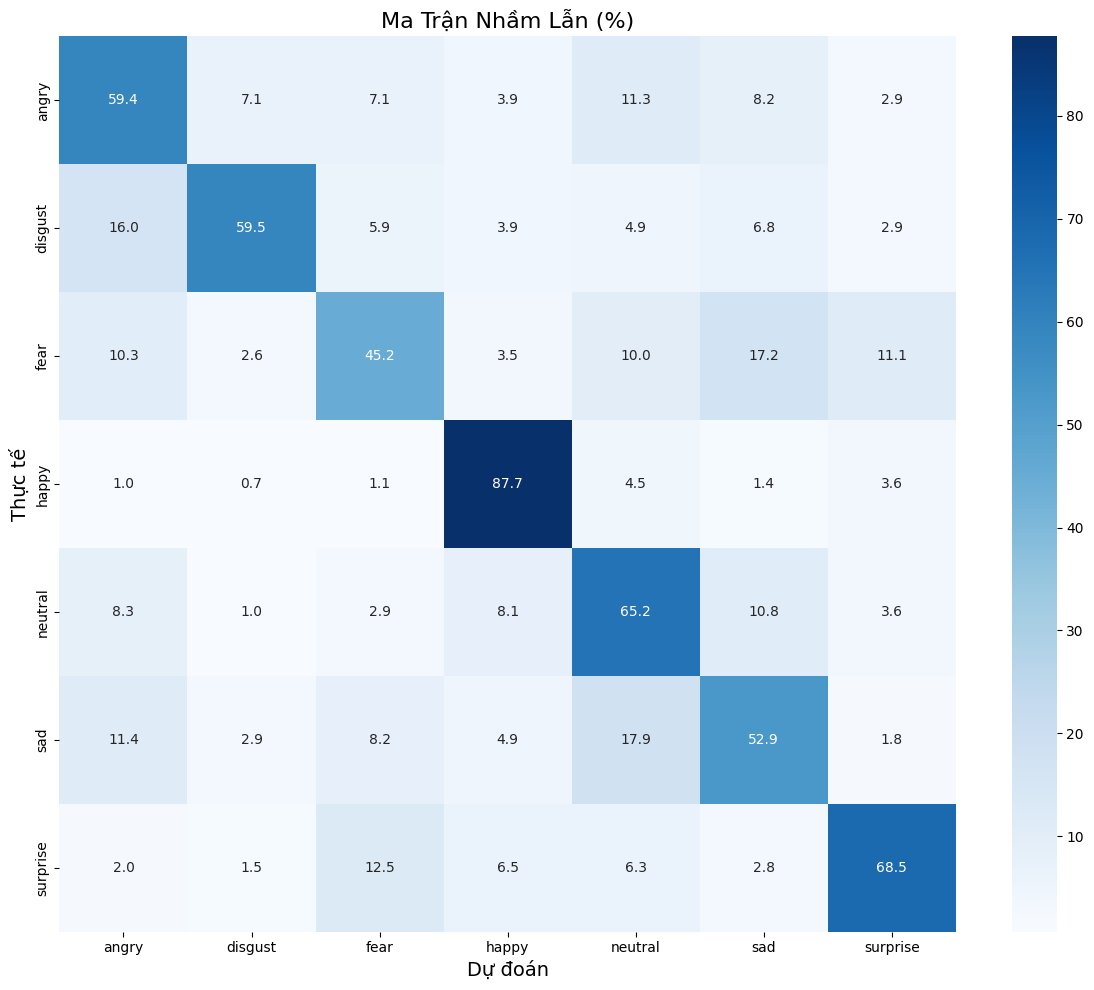

Ma trận nhầm lẫn (số lượng mẫu):
          angry  disgust  fear  happy  neutral  sad  surprise
angry       806       96    97     53      154  112        40
disgust      82      304    30     20       25   35        15
fear        147       37   644     50      143  245       158
happy        22       16    23   1907       97   31        78
neutral     136       17    48    133     1064  176        59
sad         187       48   135     80      295  872        30
surprise     24       18   154     80       77   35       842


Ma trận nhầm lẫn (%):
          angry  disgust  fear  happy  neutral   sad  surprise
angry      59.4      7.1   7.1    3.9     11.3   8.2       2.9
disgust    16.0     59.5   5.9    3.9      4.9   6.8       2.9
fear       10.3      2.6  45.2    3.5     10.0  17.2      11.1
happy       1.0      0.7   1.1   87.7      4.5   1.4       3.6
neutral     8.3      1.0   2.9    8.1     65.2  10.8       3.6
sad        11.4      2.9   8.2    4.9     17.9  52.9       1.8
surpri

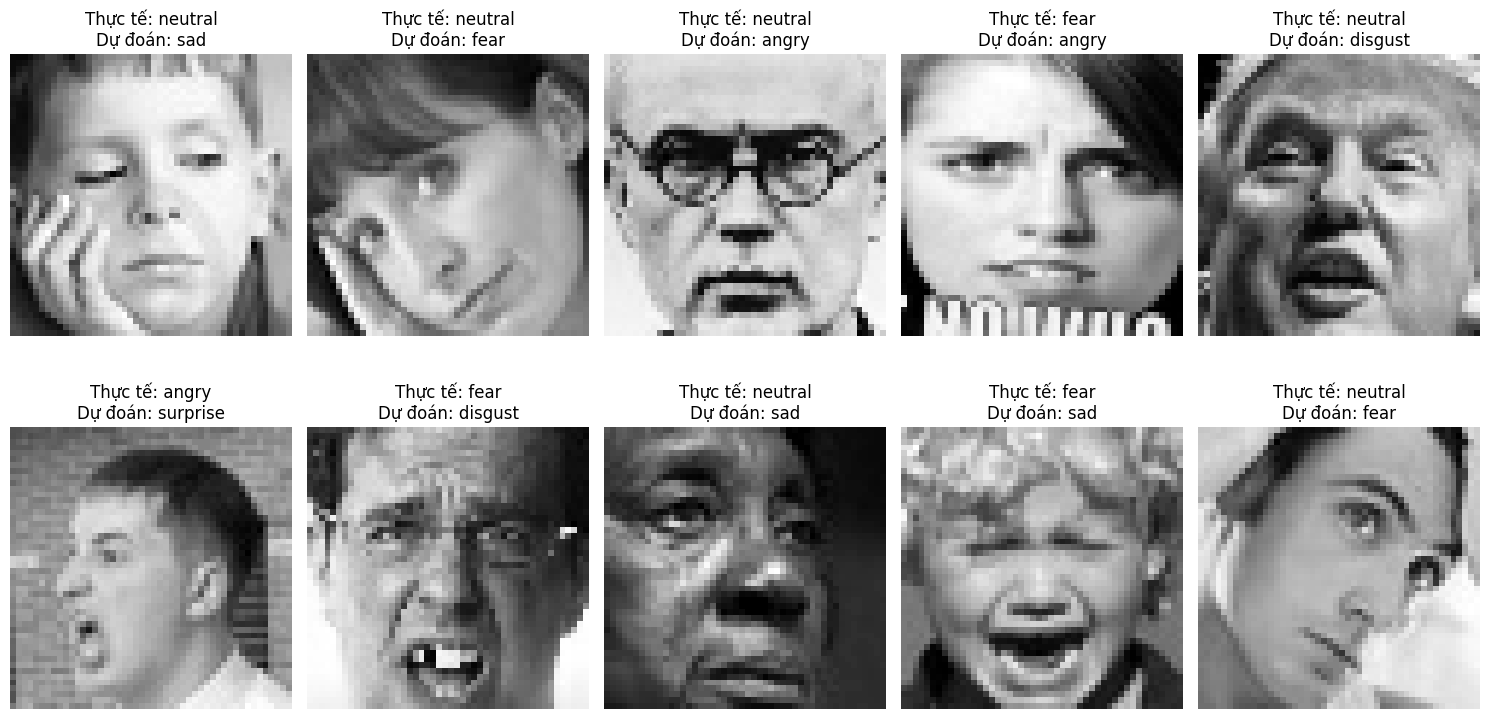

In [13]:
# Dự đoán trên tập kiểm tra sử dụng test_ds
Y_pred = []
Y_true = []

# Sử dụng test_ds trực tiếp thay vì test_set
# test_ds là một tf.data.Dataset đã được chuẩn bị sẵn
for x_batch, y_batch in test_ds:
    # Dự đoán trên batch hiện tại
    y_pred = model.predict(x_batch, verbose=0)
    
    # Lấy class có xác suất cao nhất
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Lấy nhãn thực tế từ y_batch
    # Kiểm tra xem y_batch đã là số nguyên hay đang dạng one-hot
    if len(y_batch.shape) > 1 and y_batch.shape[1] > 1:
        y_true_classes = np.argmax(y_batch, axis=1)
    else:
        y_true_classes = y_batch  # Nhãn đã ở dạng số nguyên
    
    # Thêm vào danh sách kết quả
    Y_pred.extend(y_pred_classes)
    Y_true.extend(y_true_classes)

# Đảm bảo Y_true và Y_pred là mảng numpy
Y_true = np.array(Y_true)
Y_pred = np.array(Y_pred)

# Lấy tên các lớp từ mapping đã tạo
class_names = list(combined_class_mapping.values())

# Tạo confusion matrix
cm = confusion_matrix(Y_true, Y_pred)

# Chuẩn hóa ma trận để hiển thị dưới dạng phần trăm
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 1. Hiển thị ma trận nhầm lẫn dạng heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán', fontsize=14)
plt.ylabel('Thực tế', fontsize=14)
plt.title('Ma Trận Nhầm Lẫn (%)', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Hiển thị ma trận nhầm lẫn dạng bảng số liệu
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("Ma trận nhầm lẫn (số lượng mẫu):")
print(cm_df)
print("\n")

cm_normalized_df = pd.DataFrame(cm_normalized, index=class_names, columns=class_names)
print("Ma trận nhầm lẫn (%):")
print(cm_normalized_df.round(1))
print("\n")

# 3. Hiển thị thống kê tổng hợp
# Tính tỷ lệ phân loại đúng cho từng lớp
accuracy_per_class = np.diag(cm) / np.sum(cm, axis=1)

# Tạo bảng tổng hợp hiệu suất theo lớp
performance_df = pd.DataFrame({
    'Lớp': class_names,
    'Số lượng mẫu': np.sum(cm, axis=1),
    'Phân loại đúng': np.diag(cm),
    'Độ chính xác (%)': (accuracy_per_class * 100).round(1)
})
print("Hiệu suất theo lớp:")
print(performance_df)
print("\n")

# 4. In báo cáo phân loại chi tiết
print('Báo cáo Phân loại chi tiết:')
print(classification_report(Y_true, Y_pred, target_names=class_names))

# 5. Hiển thị các ảnh bị phân loại sai
def plot_misclassified_examples(test_ds, y_true, y_pred, class_names, n_examples=10):
    # Tìm các vị trí phân loại sai
    misclassified_idx = np.where(y_true != y_pred)[0]
    
    if len(misclassified_idx) == 0:
        print("Không tìm thấy ví dụ nào bị phân loại sai!")
        return
    
    # Chọn ngẫu nhiên n ví dụ
    n_examples = min(n_examples, len(misclassified_idx))
    selected_idx = np.random.choice(misclassified_idx, n_examples, replace=False)
    
    # Lấy từng ảnh từ dataset
    images = []
    true_labels = []
    pred_labels = []
    
    # Lấy dữ liệu từ test_ds
    for i, (x, y) in enumerate(test_ds.unbatch()):
        if i in selected_idx:
            images.append(x.numpy())
            true_idx = np.where(selected_idx == i)[0][0]
            true_labels.append(y_true[selected_idx[true_idx]])
            pred_labels.append(y_pred[selected_idx[true_idx]])
            
            # Nếu đã lấy đủ số ví dụ, dừng vòng lặp
            if len(images) >= n_examples:
                break
    
    # Hiển thị ví dụ
    plt.figure(figsize=(15, 8))
    for i in range(len(images)):
        plt.subplot(2, 5, i+1)
        # Hiển thị ảnh grayscale
        img = images[i].squeeze()  # Loại bỏ chiều channel nếu có
        plt.imshow(img, cmap='gray')
        plt.title(f"Thực tế: {class_names[true_labels[i]]}\nDự đoán: {class_names[pred_labels[i]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Hiển thị một số ví dụ bị phân loại sai
plot_misclassified_examples(test_ds, Y_true, Y_pred, class_names)

In [14]:
model.save('/kaggle/working/final_model.keras')